# Scenario 3 – Natural Ventilation Decision Support

## Objective

This scenario uses the 30-minute CO₂ forecasting methodology developed in Scenario 2 to support natural ventilation decisions in Room 4.9.

The predicted future CO₂ concentration is combined with current occupancy and window status through a rule-based recommendation mechanism. The objective is to provide operational decision support rather than automated control of the building.

In [1]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor

In [2]:
# LOAD ROOM 4.9 DATASET

file_path = "room_4_9_full_dataset.csv"

df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")

display(df.head())

Dataset shape: (38692, 59)
Columns: 59


,ts,co2_iaq1,temperature_iaq1,humidity_iaq1,light_level_iaq1,pir_iaq1,co2_iaq2,temperature_iaq2,humidity_iaq2,light_level_iaq2,...,occupied_desks,free_desks,occupancy_rate,any_desk_occupied,mc_1,mc_2,mc_3,mc_4,open_windows,open_windows_binary
0,2025-09-01 20:40:00,583.0,29.3,42.5,0.0,0.0,577.0,29.2,42.5,0.0,...,0,32,0.0,0,1,0,0,0,1,1
1,2025-09-01 20:50:00,580.0,29.3,42.5,0.0,0.0,575.0,29.2,42.5,0.0,...,0,32,0.0,0,1,0,0,0,1,1
2,2025-09-01 21:00:00,577.0,29.3,42.5,0.0,0.0,571.0,29.2,42.5,0.0,...,0,32,0.0,0,1,0,0,0,1,1
3,2025-09-01 21:10:00,572.0,29.3,42.5,0.0,0.0,566.0,29.2,43.0,0.0,...,0,32,0.0,0,1,0,0,0,1,1
4,2025-09-01 21:20:00,568.0,29.3,42.5,0.0,0.0,561.0,29.2,43.0,0.0,...,0,32,0.0,0,1,0,0,0,1,1


In [3]:
# CHECK REQUIRED COLUMNS

required_columns = [
    "ts",
    "co2_avg",
    "temperature_avg",
    "humidity_avg",
    "light_level_avg",
    "pir_any",
    "open_windows",
    "occupied_desks"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")

All required columns are available.


In [4]:
# FEATURE ENGINEERING

# Convert timestamp and ensure chronological order
df["ts"] = pd.to_datetime(df["ts"])
df = df.sort_values("ts").reset_index(drop=True)

# Time-based features
df["hour"] = df["ts"].dt.hour
df["day_of_week"] = df["ts"].dt.dayofweek
df["weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Historical CO₂ features
df["co2_lag_1"] = df["co2_avg"].shift(1)
df["co2_lag_2"] = df["co2_avg"].shift(2)
df["co2_lag_3"] = df["co2_avg"].shift(3)

df["co2_change_10min"] = (
    df["co2_avg"] - df["co2_lag_1"]
)

df["co2_rolling_mean_30min"] = (
    df["co2_avg"]
      .shift(1)
      .rolling(
          window=3,
          min_periods=1
      )
      .mean()
)

# Columns required by the forecasting model
required_model_columns = [
    "co2_avg",
    "temperature_avg",
    "humidity_avg",
    "light_level_avg",
    "pir_any",
    "open_windows",
    "occupied_desks",
    "weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "co2_lag_1",
    "co2_lag_2",
    "co2_lag_3",
    "co2_change_10min",
    "co2_rolling_mean_30min"
]

# Remove only observations with missing or invalid values
# in variables required by the forecasting model.
df = (
    df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=required_model_columns)
    .reset_index(drop=True)
)

print(
    "Dataset after feature engineering:",
    df.shape
)

display(
    df[
        [
            "ts",
            "co2_avg",
            "temperature_avg",
            "humidity_avg",
            "occupied_desks",
            "open_windows",
            "co2_lag_1",
            "co2_lag_2",
            "co2_lag_3",
            "co2_change_10min",
            "co2_rolling_mean_30min"
        ]
    ].head()
)

Dataset after feature engineering: (38689, 71)


,ts,co2_avg,temperature_avg,humidity_avg,occupied_desks,open_windows,co2_lag_1,co2_lag_2,co2_lag_3,co2_change_10min,co2_rolling_mean_30min
0,2025-09-01 21:10:00,569.0,29.25,42.75,0,1,574.0,577.5,580.0,-5.0,577.166667
1,2025-09-01 21:20:00,564.5,29.25,42.75,0,1,569.0,574.0,577.5,-4.5,573.500000
2,2025-09-01 21:30:00,563.0,29.25,42.50,0,1,564.5,569.0,574.0,-1.5,569.166667
3,2025-09-01 21:40:00,560.5,29.20,42.25,0,1,563.0,564.5,569.0,-2.5,565.500000
4,2025-09-01 21:50:00,556.5,29.20,42.25,0,1,560.5,563.0,564.5,-4.0,562.666667


## 1. CO₂ Forecasting for Operational Decision Support

The HistGradientBoosting forecasting methodology selected in Scenario 2 is reproduced using the same feature set, target definition and strict chronological training procedure.

In this scenario, the trained model is subsequently applied to the available historical observations to generate 30-minute-ahead CO₂ estimates for operational analysis. These predictions are not used as a new independent evaluation of forecasting accuracy.

In [5]:
# TRAIN HISTGRADIENTBOOSTING MODEL
# Exact reproduction of the forecasting pipeline used in Scenario 2

# --------------------------------------------------
# 1. CREATE 30-MINUTE-AHEAD TARGET
# --------------------------------------------------

# Since the dataset uses 10-minute intervals,
# three future observations correspond to 30 minutes.
df["co2_target_30min"] = df["co2_avg"].shift(-3)

# Timestamp corresponding to the future target
df["target_ts_30min"] = df["ts"].shift(-3)

# --------------------------------------------------
# 2. VERIFY EXACT 30-MINUTE FORECAST HORIZON
# --------------------------------------------------

df["target_horizon"] = (
    df["target_ts_30min"] - df["ts"]
)

# Keep only observations with:
# - valid future target
# - valid future timestamp
# - target exactly 30 minutes ahead
model_df = df.dropna(
    subset=[
        "co2_target_30min",
        "target_ts_30min"
    ]
).copy()

model_df = model_df[
    model_df["target_horizon"] == pd.Timedelta(minutes=30)
].copy()

model_df = (
    model_df
    .sort_values("ts")
    .reset_index(drop=True)
)

print(
    "Valid observations for CO₂ forecasting:",
    len(model_df)
)

# --------------------------------------------------
# 3. FEATURES USED IN SCENARIO 2
# --------------------------------------------------

feature_columns = [
    "co2_avg",
    "temperature_avg",
    "humidity_avg",
    "light_level_avg",
    "pir_any",
    "open_windows",
    "occupied_desks",
    "weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "co2_lag_1",
    "co2_lag_2",
    "co2_lag_3",
    "co2_change_10min",
    "co2_rolling_mean_30min"
]

# --------------------------------------------------
# 4. CHRONOLOGICAL 80/20 SPLIT
# --------------------------------------------------

split_index = int(
    len(model_df) * 0.80
)

test_start_ts = model_df.iloc[
    split_index
]["ts"]

# --------------------------------------------------
# 5. STRICT TEMPORAL SEPARATION
# --------------------------------------------------

# Training observations are retained only when
# their future target timestamp occurs strictly
# before the beginning of the test period.
train_df = model_df[
    model_df["target_ts_30min"] < test_start_ts
].copy()

# Test observations begin at the chronological
# 80% split point.
test_df = model_df[
    model_df["ts"] >= test_start_ts
].copy()

# Prepare training and test matrices
X_train = train_df[feature_columns]
y_train = train_df["co2_target_30min"]

X_test = test_df[feature_columns]
y_test = test_df["co2_target_30min"]

# --------------------------------------------------
# 6. TRAIN FINAL MODEL SELECTED IN SCENARIO 2
# --------------------------------------------------

hgb = HistGradientBoostingRegressor(
    random_state=42
)

hgb.fit(
    X_train,
    y_train
)

print(
    "\nHistGradientBoosting model "
    "trained successfully."
)

print(
    "Training observations:",
    len(train_df)
)

print(
    "Test observations:",
    len(test_df)
)

print(
    "Test period starts:",
    test_start_ts
)

print(
    "Last training feature timestamp:",
    train_df["ts"].max()
)

print(
    "Last training target timestamp:",
    train_df["target_ts_30min"].max()
)

assert (
    train_df["target_ts_30min"].max()
    < test_df["ts"].min()
)

print("✓ Temporal leakage check passed.")

Valid observations for CO₂ forecasting: 38683

HistGradientBoosting model trained successfully.
Training observations: 30943
Test observations: 7737
Test period starts: 2026-04-04 18:50:00
Last training feature timestamp: 2026-04-04 18:10:00
Last training target timestamp: 2026-04-04 18:40:00
✓ Temporal leakage check passed.


In [6]:
# PREPARE FEATURES FOR CO₂ PREDICTION

X = df[feature_columns].copy()

print("Prediction dataset shape:", X.shape)

# Predict CO₂ 30 minutes ahead
df["predicted_co2_30min"] = hgb.predict(X)

print("Prediction completed successfully.")

display(
    df[
        [
            "ts",
            "co2_avg",
            "predicted_co2_30min",
            "occupied_desks",
            "open_windows"
        ]
    ].head(10)
)

Prediction dataset shape: (38689, 17)
Prediction completed successfully.


,ts,co2_avg,predicted_co2_30min,occupied_desks,open_windows
0,2025-09-01 21:10:00,569.0,554.726017,0,1
1,2025-09-01 21:20:00,564.5,554.726017,0,1
2,2025-09-01 21:30:00,563.0,557.095923,0,1
3,2025-09-01 21:40:00,560.5,556.743525,0,1
4,2025-09-01 21:50:00,556.5,544.694024,0,1
5,2025-09-01 22:00:00,554.0,546.185180,0,1
6,2025-09-01 22:10:00,550.5,535.963120,0,1
7,2025-09-01 22:20:00,549.0,535.436783,0,1
8,2025-09-01 22:30:00,546.5,535.084385,0,1
9,2025-09-01 22:40:00,544.5,535.084385,0,1


count    38689.000000
mean       520.208407
std        214.859997
min        381.471646
25%        419.030959
50%        453.048690
75%        522.003773
max       3519.061338
Name: predicted_co2_30min, dtype: float64


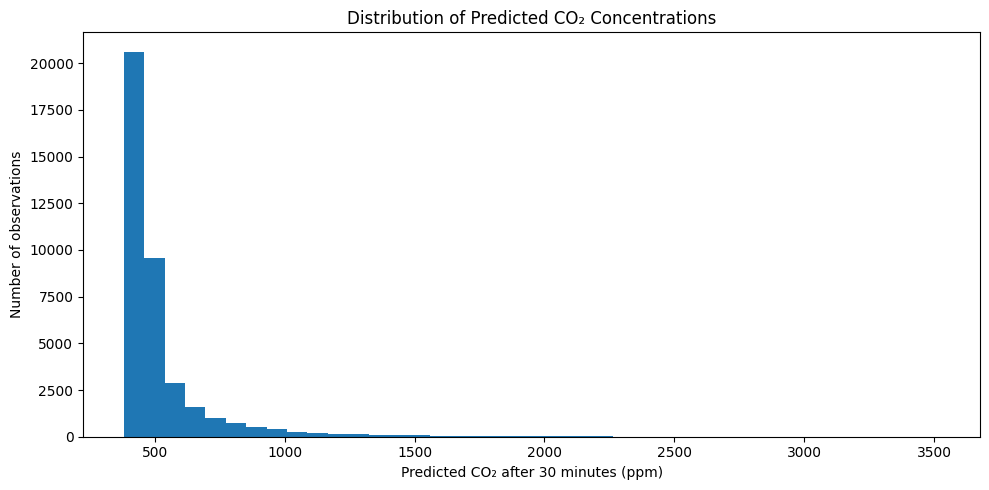

In [7]:
# DISTRIBUTION OF PREDICTED CO₂

print(df["predicted_co2_30min"].describe())

plt.figure(figsize=(10,5))

plt.hist(
    df["predicted_co2_30min"],
    bins=40
)

plt.xlabel("Predicted CO₂ after 30 minutes (ppm)")
plt.ylabel("Number of observations")
plt.title("Distribution of Predicted CO₂ Concentrations")

plt.tight_layout()
plt.show()

In [8]:
# CO₂ THRESHOLD ANALYSIS

thresholds = [800, 1000, 1200]

total = len(df)

for threshold in thresholds:

    count = (df["predicted_co2_30min"] >= threshold).sum()

    percentage = count / total * 100

    print(
        f"Predicted CO₂ ≥ {threshold} ppm : "
        f"{count} observations ({percentage:.2f}%)"
    )

Predicted CO₂ ≥ 800 ppm : 2688 observations (6.95%)
Predicted CO₂ ≥ 1000 ppm : 1341 observations (3.47%)
Predicted CO₂ ≥ 1200 ppm : 745 observations (1.93%)


In [9]:
# WINDOW STATUS DURING HIGH CO₂ EVENTS

high_co2 = df[df["predicted_co2_30min"] >= 800].copy()

summary = (
    high_co2
    .groupby("open_windows")
    .size()
    .reset_index(name="Observations")
)

summary["Percentage (%)"] = (
    summary["Observations"]
    / summary["Observations"].sum()
    * 100
).round(2)

display(summary)

,open_windows,Observations,Percentage (%)
0,1,171,6.36
1,2,794,29.54
2,3,1161,43.19
3,4,562,20.91


## 2. Occupancy, Window Status and Predicted CO₂

The operational analysis focuses primarily on occupied periods, since ventilation recommendations are meaningful when the room is actively being used.

Predicted CO₂ concentrations are examined together with occupancy levels and the current number of open windows to characterize the conditions under which additional natural ventilation may be useful.

In [10]:
# FILTER OCCUPIED PERIODS

occupied_df = df[df["occupied_desks"] > 0].copy()

print(f"Total observations      : {len(df)}")
print(f"Occupied observations   : {len(occupied_df)}")
print(f"Percentage occupied     : {len(occupied_df) / len(df) * 100:.2f}%")

display(
    occupied_df[
        [
            "ts",
            "occupied_desks",
            "open_windows",
            "co2_avg",
            "predicted_co2_30min"
        ]
    ].head()
)

Total observations      : 38689
Occupied observations   : 6304
Percentage occupied     : 16.29%


,ts,occupied_desks,open_windows,co2_avg,predicted_co2_30min
80,2025-09-02 10:30:00,1,1,555.5,563.978802
81,2025-09-02 10:40:00,1,2,557.0,559.715732
82,2025-09-02 10:50:00,1,2,563.5,588.388309
83,2025-09-02 11:00:00,1,2,573.0,608.733575
84,2025-09-02 11:10:00,1,2,585.5,628.966617


In [11]:
# PREDICTED CO₂ LEVELS DURING OCCUPIED PERIODS

occupied_summary = (
    occupied_df["predicted_co2_30min"]
    .describe()
    .round(2)
)

print(occupied_summary)

thresholds = [800, 1000, 1200]

print("\nHigh CO₂ events during occupied periods:\n")

for threshold in thresholds:

    count = (
        occupied_df["predicted_co2_30min"] >= threshold
    ).sum()

    percentage = (
        count / len(occupied_df) * 100
    )

    print(
        f"CO₂ ≥ {threshold} ppm : "
        f"{count} observations "
        f"({percentage:.2f}%)"
    )

count    6304.00
mean      806.85
std       371.73
min       411.09
25%       569.15
50%       708.86
75%       913.97
max      3519.06
Name: predicted_co2_30min, dtype: float64

High CO₂ events during occupied periods:

CO₂ ≥ 800 ppm : 2321 observations (36.82%)
CO₂ ≥ 1000 ppm : 1167 observations (18.51%)
CO₂ ≥ 1200 ppm : 657 observations (10.42%)


In [12]:
# WINDOW STATUS DURING OCCUPIED PERIODS

window_status_occupied = (
    occupied_df["open_windows"]
    .value_counts()
    .sort_index()
    .reset_index()
)

window_status_occupied.columns = [
    "Open Windows",
    "Observations"
]

window_status_occupied["Percentage (%)"] = (
    window_status_occupied["Observations"]
    / len(occupied_df)
    * 100
).round(2)

display(window_status_occupied)

,Open Windows,Observations,Percentage (%)
0,1,478,7.58
1,2,1768,28.05
2,3,2942,46.67
3,4,1116,17.70


,Open Windows,Observations,Mean CO₂,Median CO₂,Std CO₂
0,1,478,748.75,503.14,505.48
1,2,1768,834.32,702.81,436.90
2,3,2942,799.45,710.51,333.21
3,4,1116,807.71,751.12,271.43


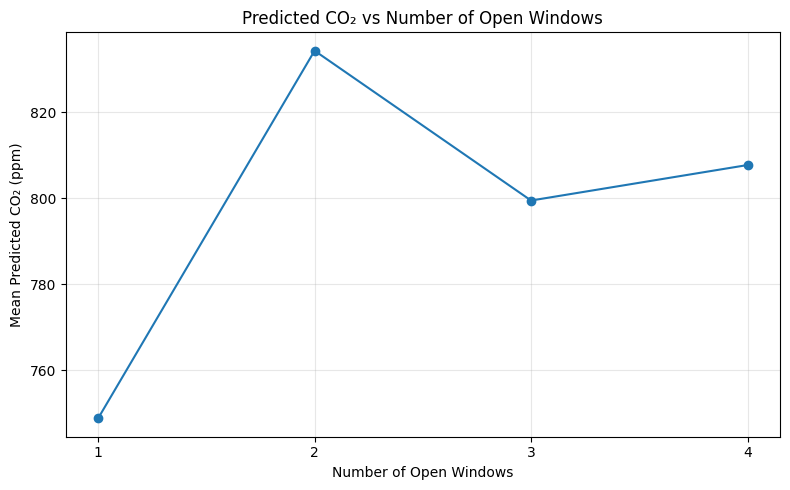

In [13]:
# EFFECT OF WINDOW OPENING ON PREDICTED CO₂

window_effect = (
    occupied_df
    .groupby("open_windows")["predicted_co2_30min"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .reset_index()
)

window_effect.columns = [
    "Open Windows",
    "Observations",
    "Mean CO₂",
    "Median CO₂",
    "Std CO₂"
]

display(window_effect)

plt.figure(figsize=(8,5))

plt.plot(
    window_effect["Open Windows"],
    window_effect["Mean CO₂"],
    marker="o"
)

plt.xticks(window_effect["Open Windows"])

plt.xlabel("Number of Open Windows")
plt.ylabel("Mean Predicted CO₂ (ppm)")
plt.title("Predicted CO₂ vs Number of Open Windows")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

,Occupied Desks,Observations,Mean CO₂,Median CO₂
0,1,2043,594.58,540.01
1,2,551,667.42,620.27
2,3,324,710.65,624.34
3,4,283,737.04,673.54
4,5,254,773.53,690.98
5,6,260,836.79,730.09
6,7,202,873.30,790.78
7,8,207,879.78,782.51
8,9,195,926.48,793.21
9,10,148,1058.80,865.11


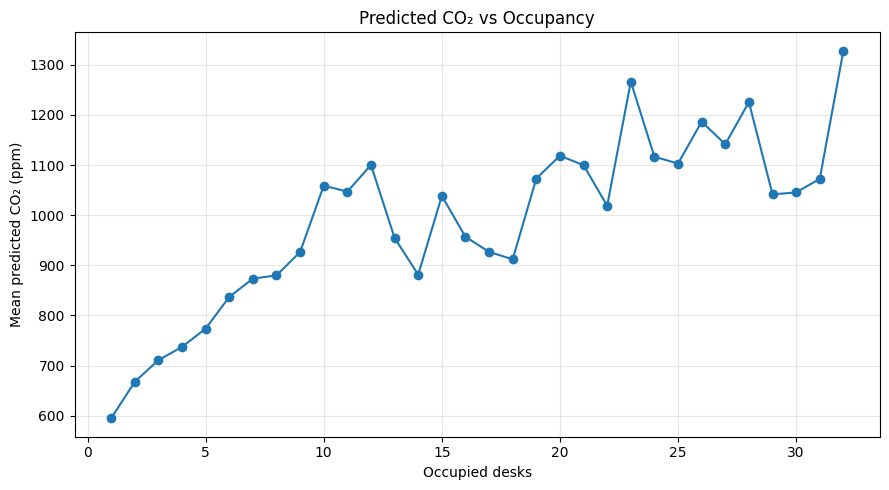

In [14]:
# EFFECT OF OCCUPANCY ON PREDICTED CO₂

occupancy_effect = (
    occupied_df
    .groupby("occupied_desks")["predicted_co2_30min"]
    .agg(["count", "mean", "median"])
    .round(2)
    .reset_index()
)

occupancy_effect.columns = [
    "Occupied Desks",
    "Observations",
    "Mean CO₂",
    "Median CO₂"
]

display(occupancy_effect)

plt.figure(figsize=(9,5))

plt.plot(
    occupancy_effect["Occupied Desks"],
    occupancy_effect["Mean CO₂"],
    marker="o"
)

plt.xlabel("Occupied desks")
plt.ylabel("Mean predicted CO₂ (ppm)")
plt.title("Predicted CO₂ vs Occupancy")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

,Open Windows,Observations,Mean Occupancy,Median Occupancy,Mean Predicted CO₂,Median Predicted CO₂
0,1,478,3.37,1.0,748.75,503.14
1,2,1768,7.19,3.0,834.32,702.81
2,3,2942,8.90,5.0,799.45,710.51
3,4,1116,10.07,7.0,807.71,751.12


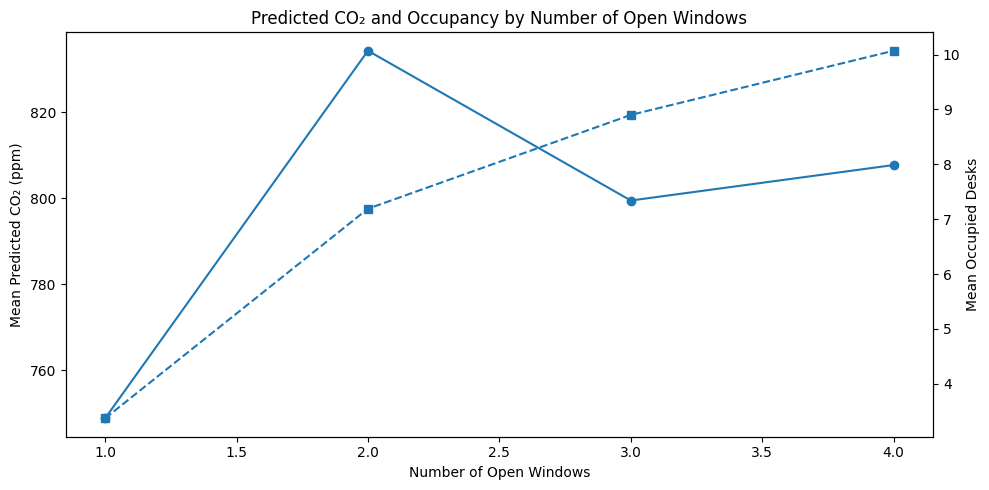

In [15]:
# COMBINED ANALYSIS:
# OPEN WINDOWS - OCCUPANCY - PREDICTED CO₂

ventilation_analysis = (
    occupied_df
    .groupby("open_windows")
    .agg(
        observations=("predicted_co2_30min", "size"),
        mean_occupancy=("occupied_desks", "mean"),
        median_occupancy=("occupied_desks", "median"),
        mean_predicted_co2=("predicted_co2_30min", "mean"),
        median_predicted_co2=("predicted_co2_30min", "median")
    )
    .reset_index()
)

ventilation_analysis.columns = [
    "Open Windows",
    "Observations",
    "Mean Occupancy",
    "Median Occupancy",
    "Mean Predicted CO₂",
    "Median Predicted CO₂"
]

ventilation_analysis[
    [
        "Mean Occupancy",
        "Median Occupancy",
        "Mean Predicted CO₂",
        "Median Predicted CO₂"
    ]
] = ventilation_analysis[
    [
        "Mean Occupancy",
        "Median Occupancy",
        "Mean Predicted CO₂",
        "Median Predicted CO₂"
    ]
].round(2)

display(ventilation_analysis)

# MEAN OCCUPANCY AND PREDICTED CO₂ BY NUMBER OF OPEN WINDOWS

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    ventilation_analysis["Open Windows"],
    ventilation_analysis["Mean Predicted CO₂"],
    marker="o",
    label="Mean Predicted CO₂"
)

ax1.set_xlabel("Number of Open Windows")
ax1.set_ylabel("Mean Predicted CO₂ (ppm)")

ax2 = ax1.twinx()

ax2.plot(
    ventilation_analysis["Open Windows"],
    ventilation_analysis["Mean Occupancy"],
    marker="s",
    linestyle="--",
    label="Mean Occupancy"
)

ax2.set_ylabel("Mean Occupied Desks")

ax1.set_title(
    "Predicted CO₂ and Occupancy by Number of Open Windows"
)

fig.tight_layout()

fig.savefig(
    "co2_occupancy_by_open_windows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Natural Ventilation Recommendation Engine

A rule-based decision-support mechanism combines predicted CO₂ concentration, current occupancy and the number of already open windows.

The mechanism determines a desired total number of open windows and expresses the final recommendation as the number of additional windows that should be opened. The recommendations are intended as indicative decision support rather than automated ventilation control.

In [16]:
# NATURAL VENTILATION RECOMMENDATION ENGINE
# Rule-based decision-support mechanism using:
# predicted CO₂, occupancy and current number of open windows.

# CO₂ thresholds used by the recommendation logic
CO2_GOOD = 800
CO2_MODERATE = 1000
CO2_HIGH = 1200

# Occupancy thresholds used to scale ventilation recommendations
LOW_OCCUPANCY_MAX = 5
MEDIUM_OCCUPANCY_MAX = 15

# Maximum number of windows available in Room 4.9
MAX_WINDOWS = 4


def ventilation_recommendation(
    predicted_co2,
    occupied_desks,
    open_windows
):

    # --------------------------------------------------
    # 1. Determine desired total number of open windows
    # --------------------------------------------------

    # Empty room
    if occupied_desks == 0:
        target_windows = 0

    # Good predicted air quality
    elif predicted_co2 < CO2_GOOD:
        target_windows = open_windows

    # Moderate predicted CO₂
    elif predicted_co2 < CO2_MODERATE:

        if occupied_desks <= LOW_OCCUPANCY_MAX:
            target_windows = 1

        elif occupied_desks <= MEDIUM_OCCUPANCY_MAX:
            target_windows = 2

        else:
            target_windows = 3

    # High predicted CO₂
    elif predicted_co2 < CO2_HIGH:

        if occupied_desks <= LOW_OCCUPANCY_MAX:
            target_windows = 2

        elif occupied_desks <= MEDIUM_OCCUPANCY_MAX:
            target_windows = 3

        else:
            target_windows = 4

    # Very high predicted CO₂
    else:
        target_windows = MAX_WINDOWS

    # Ensure recommendation does not exceed room capacity
    target_windows = min(
        target_windows,
        MAX_WINDOWS
    )

    # Number of additional windows required
    additional_windows = max(
        target_windows - open_windows,
        0
    )

    # --------------------------------------------------
    # 2. Generate recommendation text
    # --------------------------------------------------

    if occupied_desks == 0:
        recommendation = "No action - room empty"

    elif predicted_co2 < CO2_GOOD:
        recommendation = (
            "No additional ventilation required"
        )

    elif additional_windows == 0:
        recommendation = (
            "Current ventilation adequate"
        )

    else:
        recommendation = (
            f"Open {additional_windows} additional window(s)"
        )

    return pd.Series(
        [
            target_windows,
            additional_windows,
            recommendation
        ]
    )


# Apply the rule-based recommendation mechanism
df[
    [
        "recommended_open_windows",
        "additional_windows_to_open",
        "ventilation_recommendation"
    ]
] = df.apply(
    lambda row: ventilation_recommendation(
        row["predicted_co2_30min"],
        row["occupied_desks"],
        row["open_windows"]
    ),
    axis=1
)


print(
    "Ventilation recommendation engine "
    "completed successfully."
)

display(
    df[
        [
            "ts",
            "co2_avg",
            "predicted_co2_30min",
            "occupied_desks",
            "open_windows",
            "recommended_open_windows",
            "additional_windows_to_open",
            "ventilation_recommendation"
        ]
    ].head(20)
)

Ventilation recommendation engine completed successfully.


,ts,co2_avg,predicted_co2_30min,occupied_desks,open_windows,recommended_open_windows,additional_windows_to_open,ventilation_recommendation
0,2025-09-01 21:10:00,569.0,554.726017,0,1,0,0,No action - room empty
1,2025-09-01 21:20:00,564.5,554.726017,0,1,0,0,No action - room empty
2,2025-09-01 21:30:00,563.0,557.095923,0,1,0,0,No action - room empty
3,2025-09-01 21:40:00,560.5,556.743525,0,1,0,0,No action - room empty
4,2025-09-01 21:50:00,556.5,544.694024,0,1,0,0,No action - room empty
5,2025-09-01 22:00:00,554.0,546.185180,0,1,0,0,No action - room empty
6,2025-09-01 22:10:00,550.5,535.963120,0,1,0,0,No action - room empty
7,2025-09-01 22:20:00,549.0,535.436783,0,1,0,0,No action - room empty
8,2025-09-01 22:30:00,546.5,535.084385,0,1,0,0,No action - room empty
9,2025-09-01 22:40:00,544.5,535.084385,0,1,0,0,No action - room empty


In [17]:
# RECOMMENDATION ENGINE DURING OCCUPIED PERIODS

occupied_df = df[df["occupied_desks"] > 0].copy()

display(
    occupied_df[
        [
            "ts",
            "occupied_desks",
            "open_windows",
            "predicted_co2_30min",
            "recommended_open_windows",
            "additional_windows_to_open",
            "ventilation_recommendation"
        ]
    ].head(30)
)

,ts,occupied_desks,open_windows,predicted_co2_30min,recommended_open_windows,additional_windows_to_open,ventilation_recommendation
80,2025-09-02 10:30:00,1,1,563.978802,1,0,No additional ventilation required
81,2025-09-02 10:40:00,1,2,559.715732,2,0,No additional ventilation required
82,2025-09-02 10:50:00,1,2,588.388309,2,0,No additional ventilation required
83,2025-09-02 11:00:00,1,2,608.733575,2,0,No additional ventilation required
84,2025-09-02 11:10:00,1,2,628.966617,2,0,No additional ventilation required
85,2025-09-02 11:20:00,1,2,648.694143,2,0,No additional ventilation required
86,2025-09-02 11:30:00,1,2,646.873959,2,0,No additional ventilation required
113,2025-09-02 16:00:00,1,2,555.010033,2,0,No additional ventilation required
218,2025-09-03 09:30:00,1,1,455.033696,1,0,No additional ventilation required
224,2025-09-03 10:30:00,1,1,578.625221,1,0,No additional ventilation required


In [18]:
# RECOMMENDATION SUMMARY

recommendation_summary = (
    occupied_df
    .groupby(
        "ventilation_recommendation",
        observed=True
    )
    .agg(
        Observations=("predicted_co2_30min", "size"),
        Mean_Predicted_CO2=("predicted_co2_30min", "mean"),
        Median_Predicted_CO2=("predicted_co2_30min", "median"),
        Mean_Occupancy=("occupied_desks", "mean"),
        Mean_Open_Windows=("open_windows", "mean")
    )
    .reset_index()
)

recommendation_summary["Percentage (%)"] = (
    recommendation_summary["Observations"]
    / len(occupied_df)
    * 100
)

recommendation_summary[
    [
        "Mean_Predicted_CO2",
        "Median_Predicted_CO2",
        "Mean_Occupancy",
        "Mean_Open_Windows",
        "Percentage (%)"
    ]
] = (
    recommendation_summary[
        [
            "Mean_Predicted_CO2",
            "Median_Predicted_CO2",
            "Mean_Occupancy",
            "Mean_Open_Windows",
            "Percentage (%)"
        ]
    ]
    .round(2)
)

recommendation_summary = recommendation_summary.sort_values(
    "Mean_Predicted_CO2"
)

display(recommendation_summary)

,ventilation_recommendation,Observations,Mean_Predicted_CO2,Median_Predicted_CO2,Mean_Occupancy,Mean_Open_Windows,Percentage (%)
1,No additional ventilation required,3983,607.02,608.39,4.44,2.70,63.18
0,Current ventilation adequate,1346,955.09,910.39,12.94,3.17,21.35
2,Open 1 additional window(s),588,1309.04,1193.64,17.10,2.68,9.33
3,Open 2 additional window(s),331,1531.84,1335.54,17.63,1.96,5.25
4,Open 3 additional window(s),56,1898.09,1687.91,13.07,1.00,0.89


## 4. Window Opening Event Analysis

Actual window-opening events are additionally examined to investigate the subsequent evolution of CO₂ under relatively stable operating conditions.

Only events with continuous 10-minute measurements, positive and stable occupancy, and an unchanged window configuration during the following 60 minutes are retained. This analysis is observational and should not be interpreted as a controlled causal experiment.

In [19]:
# DETECT WINDOW OPENING EVENTS DURING OCCUPIED PERIODS

occupied_df = (
    occupied_df
    .sort_values("ts")
    .reset_index(drop=True)
)

occupied_df["previous_open_windows"] = (
    occupied_df["open_windows"].shift(1)
)

# Detect events where the number of open windows increases
# during occupied periods.
window_events = occupied_df[
    occupied_df["open_windows"]
    > occupied_df["previous_open_windows"]
].copy()

window_events["windows_added"] = (
    window_events["open_windows"]
    - window_events["previous_open_windows"]
)

print(
    "Candidate window opening events:",
    len(window_events)
)

display(
    window_events[
        [
            "ts",
            "previous_open_windows",
            "open_windows",
            "windows_added",
            "occupied_desks",
            "co2_avg",
            "predicted_co2_30min"
        ]
    ].head(20)
)

Candidate window opening events: 475


,ts,previous_open_windows,open_windows,windows_added,occupied_desks,co2_avg,predicted_co2_30min
1,2025-09-02 10:40:00,1.0,2,1.0,1,557.0,559.715732
10,2025-09-03 10:50:00,1.0,2,1.0,1,565.5,607.640667
24,2025-09-04 14:20:00,1.0,3,2.0,1,447.5,452.907812
28,2025-09-05 10:50:00,2.0,3,1.0,1,454.0,463.961086
59,2025-09-09 17:00:00,1.0,2,1.0,1,417.5,422.874322
72,2025-09-15 10:50:00,2.0,3,1.0,1,437.0,441.070382
82,2025-09-16 15:20:00,1.0,2,1.0,1,563.0,605.956439
86,2025-09-16 16:00:00,2.0,3,1.0,1,638.0,656.219930
98,2025-09-16 18:40:00,2.0,3,1.0,1,712.5,699.233480
117,2025-09-17 18:50:00,1.0,3,2.0,1,587.5,616.665478


In [20]:
# EFFECT OF WINDOW OPENING ON CO₂ LEVELS
# Stable occupancy and stable window configuration for 60 minutes

# Work on the complete chronological dataset
analysis_source = (
    df
    .sort_values("ts")
    .reset_index(drop=True)
    .copy()
)

analysis_source["previous_open_windows"] = (
    analysis_source["open_windows"].shift(1)
)

# Candidate events across the complete dataset:
# increase in the number of open windows
candidate_indices = analysis_source.index[
    analysis_source["open_windows"]
    > analysis_source["previous_open_windows"]
].tolist()

stable_window_events = []

for idx in candidate_indices:

    # Need the event row + 6 future 10-minute observations
    if idx + 6 >= len(analysis_source):
        continue

    event_window = analysis_source.loc[idx:idx + 6].copy()

    # --------------------------------------------------
    # 1. Verify exact 10-minute temporal continuity
    # --------------------------------------------------

    expected_times = pd.date_range(
        start=analysis_source.loc[idx, "ts"],
        periods=7,
        freq="10min"
    )

    if not np.array_equal(
        event_window["ts"].to_numpy(),
        expected_times.to_numpy()
    ):
        continue

    # --------------------------------------------------
    # 2. Require occupied room
    # --------------------------------------------------

    initial_occupancy = analysis_source.loc[
        idx,
        "occupied_desks"
    ]

    if initial_occupancy <= 0:
        continue

    # --------------------------------------------------
    # 3. Require stable occupancy for 60 minutes
    # --------------------------------------------------

    if not (
        event_window["occupied_desks"]
        == initial_occupancy
    ).all():
        continue

    # --------------------------------------------------
    # 4. Require stable window configuration
    #    for the following 60 minutes
    # --------------------------------------------------

    opened_windows = analysis_source.loc[
        idx,
        "open_windows"
    ]

    if not (
        event_window["open_windows"]
        == opened_windows
    ).all():
        continue

    # --------------------------------------------------
    # 5. Calculate CO₂ change after the event
    # --------------------------------------------------

    co2_before = analysis_source.loc[
        idx,
        "co2_avg"
    ]

    stable_window_events.append(
        {
            "ts": analysis_source.loc[idx, "ts"],

            "previous_open_windows":
                analysis_source.loc[
                    idx,
                    "previous_open_windows"
                ],

            "open_windows": opened_windows,

            "windows_added":
                opened_windows
                - analysis_source.loc[
                    idx,
                    "previous_open_windows"
                ],

            "occupied_desks": initial_occupancy,

            "co2_before": co2_before,

            "delta_10min":
                analysis_source.loc[
                    idx + 1,
                    "co2_avg"
                ] - co2_before,

            "delta_20min":
                analysis_source.loc[
                    idx + 2,
                    "co2_avg"
                ] - co2_before,

            "delta_30min":
                analysis_source.loc[
                    idx + 3,
                    "co2_avg"
                ] - co2_before,

            "delta_40min":
                analysis_source.loc[
                    idx + 4,
                    "co2_avg"
                ] - co2_before,

            "delta_50min":
                analysis_source.loc[
                    idx + 5,
                    "co2_avg"
                ] - co2_before,

            "delta_60min":
                analysis_source.loc[
                    idx + 6,
                    "co2_avg"
                ] - co2_before
        }
    )

stable_window_events = pd.DataFrame(
    stable_window_events
)

print(
    "Valid window opening events "
    "with stable occupancy and stable windows:",
    len(stable_window_events)
)

display(
    stable_window_events.head(20)
)

Valid window opening events with stable occupancy and stable windows: 34


,ts,previous_open_windows,open_windows,windows_added,occupied_desks,co2_before,delta_10min,delta_20min,delta_30min,delta_40min,delta_50min,delta_60min
0,2025-09-16 16:00:00,2.0,3,1.0,1,638.0,7.5,19.0,24.0,30.5,40.5,49.5
1,2025-09-18 10:20:00,1.0,2,1.0,1,453.5,2.5,8.5,20.0,33.5,50.0,73.0
2,2025-09-30 09:30:00,2.0,3,1.0,1,543.0,1.0,3.5,7.5,18.0,30.5,42.0
3,2025-10-01 09:20:00,2.0,3,1.0,1,474.5,4.0,5.0,5.5,7.0,7.5,7.5
4,2025-10-07 08:30:00,2.0,3,1.0,1,550.0,6.0,14.0,31.0,56.0,79.0,98.5
5,2025-10-11 15:40:00,1.0,3,2.0,1,458.0,-8.0,-7.0,-2.5,6.5,14.5,20.5
6,2025-11-21 13:20:00,2.0,3,1.0,9,663.0,-12.0,-16.0,-17.5,-16.0,-15.5,-14.0
7,2025-12-02 08:20:00,3.0,4,1.0,1,508.0,7.5,14.0,19.0,24.0,31.0,38.0
8,2025-12-08 20:00:00,1.0,2,1.0,1,681.0,-9.0,-18.0,-29.0,-34.0,-41.5,-50.0
9,2025-12-09 08:20:00,2.0,3,1.0,2,468.0,13.0,32.5,53.5,80.5,97.0,110.0


In [21]:
# SUMMARY OF CO₂ CHANGE AFTER WINDOW OPENING
# Stable occupancy and stable window configuration

delta_columns = [
    "delta_10min",
    "delta_20min",
    "delta_30min",
    "delta_40min",
    "delta_50min",
    "delta_60min"
]

stable_co2_summary = pd.DataFrame({
    "Mean ΔCO₂ (ppm)": (
        stable_window_events[delta_columns].mean()
    ),
    "Median ΔCO₂ (ppm)": (
        stable_window_events[delta_columns].median()
    )
}).round(2)

display(stable_co2_summary)

print(
    "\nAverage number of occupied desks:",
    round(
        stable_window_events["occupied_desks"].mean(),
        2
    )
)

print(
    "Average CO₂ at window opening:",
    round(
        stable_window_events["co2_before"].mean(),
        2
    ),
    "ppm"
)

print(
    "Average number of windows added:",
    round(
        stable_window_events["windows_added"].mean(),
        2
    )
)

,Mean ΔCO₂ (ppm),Median ΔCO₂ (ppm)
delta_10min,0.54,0.50
delta_20min,8.31,5.25
delta_30min,14.99,12.25
delta_40min,25.00,19.25
delta_50min,34.00,30.75
delta_60min,42.12,37.75



Average number of occupied desks: 2.94
Average CO₂ at window opening: 711.44 ppm
Average number of windows added: 1.03


In [22]:
# CO₂ BY OCCUPANCY RANGE AND NUMBER OF OPEN WINDOWS

# Use occupied periods only
analysis_df = occupied_df.copy()

# Define occupancy groups
occupancy_bins = [0, 5, 10, 15, 20, 25, 32]

occupancy_labels = [
    "1-5",
    "6-10",
    "11-15",
    "16-20",
    "21-25",
    "26-32"
]

analysis_df["occupancy_group"] = pd.cut(
    analysis_df["occupied_desks"],
    bins=occupancy_bins,
    labels=occupancy_labels,
    include_lowest=True
)

# Aggregate statistics
co2_window_summary = (
    analysis_df
    .groupby(
        ["occupancy_group", "open_windows"],
        observed=True
    )
    .agg(
        Observations=("co2_avg", "size"),
        Mean_CO2=("co2_avg", "mean"),
        Median_CO2=("co2_avg", "median"),
        Std_CO2=("co2_avg", "std"),
        Mean_Occupancy=("occupied_desks", "mean")
    )
    .reset_index()
)

# Round numerical columns
co2_window_summary[
    [
        "Mean_CO2",
        "Median_CO2",
        "Std_CO2",
        "Mean_Occupancy"
    ]
] = (
    co2_window_summary[
        [
            "Mean_CO2",
            "Median_CO2",
            "Std_CO2",
            "Mean_Occupancy"
        ]
    ]
    .round(2)
)

print(
    "CO₂ comparison by occupancy group "
    "and number of open windows:\n"
)

display(co2_window_summary)

CO₂ comparison by occupancy group and number of open windows:



,occupancy_group,open_windows,Observations,Mean_CO2,Median_CO2,Std_CO2,Mean_Occupancy
0,1-5,1,403,611.38,469.50,304.45,1.27
1,1-5,2,1051,630.87,561.50,282.92,1.69
2,1-5,3,1536,650.86,567.00,318.52,2.04
3,1-5,4,465,627.58,579.50,181.25,2.35
4,6-10,1,37,1127.45,858.00,543.53,8.14
5,6-10,2,293,911.70,782.00,457.77,7.68
6,6-10,3,434,816.42,709.00,349.32,7.70
7,6-10,4,248,771.60,699.75,294.70,7.95
8,11-15,1,12,1565.83,1081.50,996.28,12.58
9,11-15,2,110,914.76,743.50,485.63,13.13


In [23]:
# PIVOT TABLE - MEAN CO₂

mean_co2_pivot = co2_window_summary.pivot(
    index="occupancy_group",
    columns="open_windows",
    values="Mean_CO2"
)

mean_co2_pivot.columns = [
    f"{int(col)} open window(s)"
    for col in mean_co2_pivot.columns
]

print("Mean CO₂ (ppm):")
display(mean_co2_pivot)

Mean CO₂ (ppm):


,1 open window(s),2 open window(s),3 open window(s),4 open window(s)
occupancy_group,,,,
1-5,611.38,630.87,650.86,627.58
6-10,1127.45,911.70,816.42,771.60
11-15,1565.83,914.76,915.34,925.72
16-20,1003.08,1127.06,924.36,891.87
21-25,851.29,1144.99,1045.27,1036.94
26-32,1996.52,1123.82,1054.45,977.27


In [24]:
# PIVOT TABLE - NUMBER OF OBSERVATIONS

count_pivot = co2_window_summary.pivot(
    index="occupancy_group",
    columns="open_windows",
    values="Observations"
)

count_pivot.columns = [
    f"{int(col)} open window(s)"
    for col in count_pivot.columns
]

print("Number of observations:")
display(count_pivot)

Number of observations:


,1 open window(s),2 open window(s),3 open window(s),4 open window(s)
occupancy_group,,,,
1-5,403,1051,1536,465
6-10,37,293,434,248
11-15,12,110,240,111
16-20,6,86,262,76
21-25,7,155,283,127
26-32,13,73,187,89


In [25]:
# ROBUST SUMMARY OF CO₂ CHANGE AFTER WINDOW OPENING

robust_co2_summary = pd.DataFrame({
    "Median ΔCO₂ (ppm)":
        stable_window_events[delta_columns].median(),

    "Q1 ΔCO₂ (ppm)":
        stable_window_events[delta_columns].quantile(0.25),

    "Q3 ΔCO₂ (ppm)":
        stable_window_events[delta_columns].quantile(0.75)
}).round(2)

robust_co2_summary["IQR (ppm)"] = (
    robust_co2_summary["Q3 ΔCO₂ (ppm)"]
    - robust_co2_summary["Q1 ΔCO₂ (ppm)"]
).round(2)

display(robust_co2_summary)

,Median ΔCO₂ (ppm),Q1 ΔCO₂ (ppm),Q3 ΔCO₂ (ppm),IQR (ppm)
delta_10min,0.50,-6.25,7.50,13.75
delta_20min,5.25,-3.12,16.25,19.37
delta_30min,12.25,-2.50,25.75,28.25
delta_40min,19.25,0.38,33.50,33.12
delta_50min,30.75,3.00,44.25,41.25
delta_60min,37.75,-0.94,54.25,55.19


## 5. Scenario 3 Summary

The analysis demonstrates how 30-minute CO₂ forecasts can be transformed into operational decision-support information by combining expected air quality, occupancy and current window status.

The recommendation mechanism activates selectively, while the historical analysis indicates that the relationship between natural ventilation and CO₂ depends strongly on room occupancy and operating conditions.

The window-opening event analysis further shows substantial variability in the subsequent CO₂ response, supporting the use of a multi-factor recommendation mechanism rather than a fixed assumption about the effect of opening additional windows.